<a href="https://colab.research.google.com/github/gilad-altshuler/Three_Body_RNN/blob/main/notebooks/5_Neural_recordings_inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys, os
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Running in Colab. Cloning repo...")
    !git clone https://github.com/gilad-altshuler/Three_Body_RNN
    %cd Three_Body_RNN
    ROOT = Path(".").resolve()

    # Load Arial font
    !wget -O Arial.ttf "https://github.com/matomo-org/travis-scripts/raw/master/fonts/Arial.ttf"

else:
    print("Not running in Colab.")
    ROOT = Path(__file__).resolve().parent.parent
    sys.path.append(str(ROOT))
    sys.path.insert(0, str(ROOT.parent / "lowrank_inference"))

Running in Colab. Cloning repo...
Cloning into 'Three_Body_RNN'...
remote: Enumerating objects: 1516, done.
remote: Counting objects: 100% (264/264), done.
remote: Compressing objects: 100% (199/199), done.
remote: Total 1516 (delta 137), reused 130 (delta 59), pack-reused 1252 (from 2)
Receiving objects: 100% (1516/1516), 487.31 MiB | 14.73 MiB/s, done.
Resolving deltas: 100% (816/816), done.
Updating files: 100% (107/107), done.
/content/Three_Body_RNN
--2026-03-25 10:35:31--  https://github.com/matomo-org/travis-scripts/raw/master/fonts/Arial.ttf
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/matomo-org/travis-scripts/master/fonts/Arial.ttf [following]
--2026-03-25 10:35:33--  https://raw.githubusercontent.com/matomo-org/travis-scripts/master/fonts/Arial.ttf
Resolving raw.githubusercontent.com (raw.githubuserconten

In [2]:
import torch
import random
from torch import nn
import numpy as np
import copy
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import pickle

%matplotlib inline
if IN_COLAB:
  fm.fontManager.addfont('Arial.ttf')
  arial_fp = fm.FontProperties(fname='Arial.ttf')
  plt.rcParams['font.family'] = arial_fp.get_name()
else:
  plt.rcParams['font.family'] = 'Arial'
plt.rcParams["font.size"] = 10
import seaborn as sns

In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [4]:
SEED = 3150
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [5]:
rec_all = {}

In [6]:
FIG_DIR = ROOT / "notebooks" / "figures"

# Mante-inference

In [7]:
DATA_DIR = ROOT / "data" / "mante_inference"

In [8]:
with open(DATA_DIR / "r2s.pkl", "rb") as f:
    r2s = pickle.load(f)

In [9]:
SAMPLES = 30
RANKS = 5

# Prepare data
ranks = range(1,RANKS+1)

metric_names = ['$R^2$',]
models = ["RNN", "HORNN", "TBRNN"]

r2s['RNN'] = r2s['test']['rnn']
r2s['HORNN'] = r2s['test']['hornn']
r2s['TBRNN'] = r2s['test']['tbrnn']

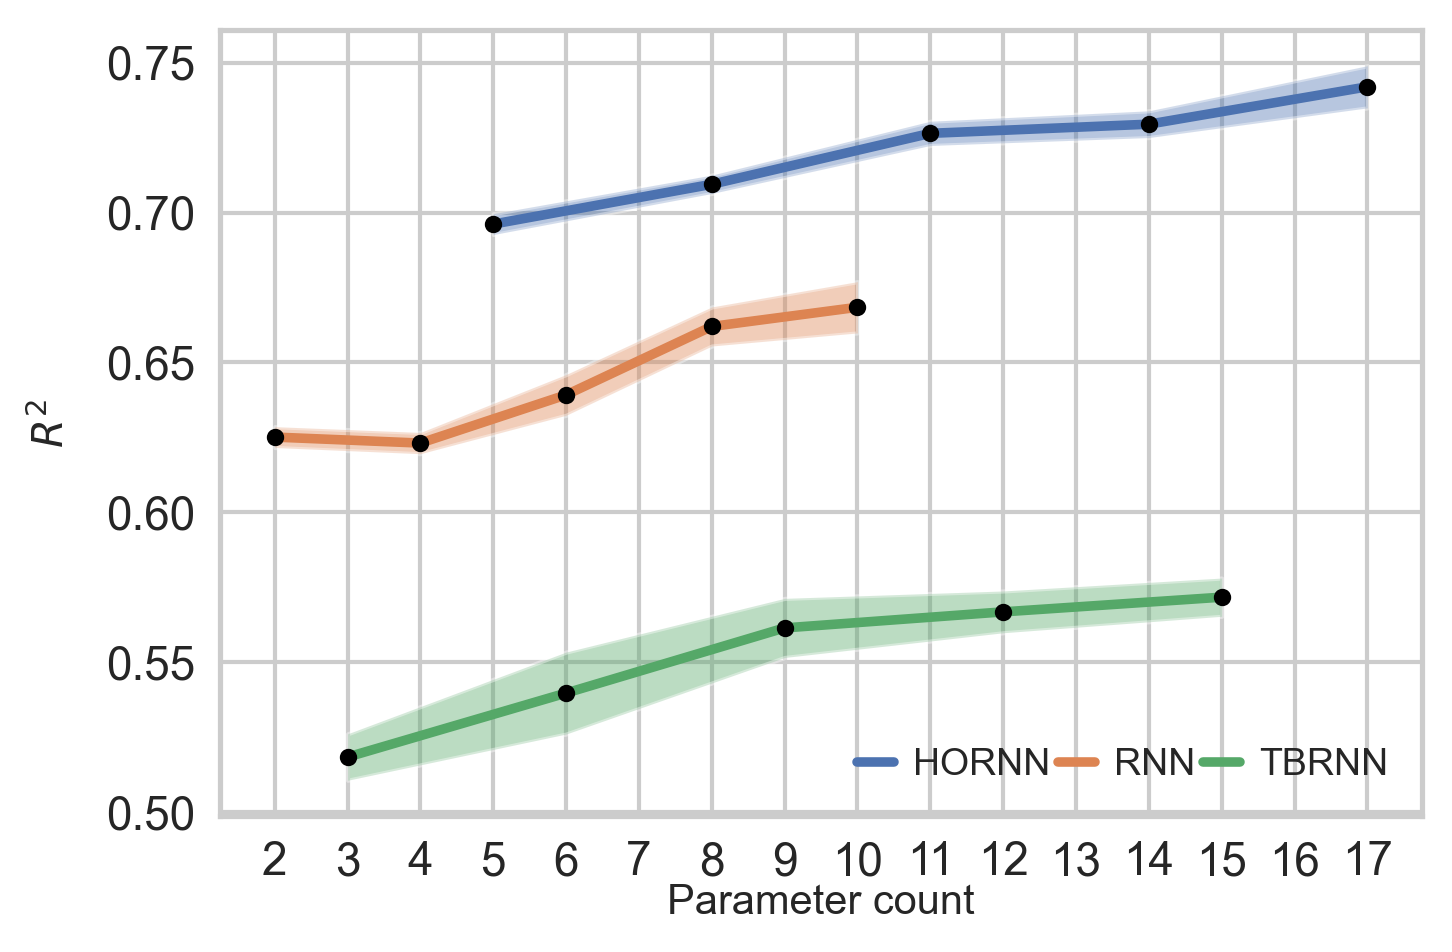

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Theme FIRST (applies to objects created after this line)
sns.set_theme(style="whitegrid", font_scale=1)

# Plot
fig, axes = plt.subplots(1, 1, figsize=(5, 4/3*2.5), dpi=300)

for ax, m in zip([axes,], metric_names):

    records = []
    for model in models:
        mean = np.mean(r2s[model], axis=-1)
        ste  = np.std(r2s[model], axis=-1) / (SAMPLES**0.5)
        d_err, u_err = mean - ste, mean + ste
        for rank in ranks:
            i = rank-1
            if model == 'TBRNN':
                parameter_count = 3*ranks[i]
            elif model == 'HORNN':
                parameter_count = 3*ranks[i] + 2
            elif model == 'RNN':
                parameter_count = 2*ranks[i]
            else:
                raise ValueError(f"Unknown model {model}")
            records.append({
                "Rank"   : ranks[i],
                "Params" : parameter_count,
                "Metric" : mean[i],
                "u_err"  : u_err[i],
                "d_err"  : d_err[i],
                "Model"  : model
            })

    df = pd.DataFrame(records)

    # Plot each model with ribbon
    for model, sub in df.groupby("Model"):
        sub = sub.sort_values("Params")  # important for fill_between

        sns.lineplot(
            ax=ax, data=sub, x="Params", y="Metric",
            label=model,
            linestyle="-",
            linewidth=2.3, zorder=1
        )

        ax.fill_between(
            sub["Params"].to_numpy(),
            sub["d_err"].to_numpy(),
            sub["u_err"].to_numpy(),
            alpha=0.4
        )

        ax.scatter(sub["Params"], sub["Metric"], s=10, color="black", zorder=2)

    # Labels and formatting
    ax.set_xlabel("Parameter count", fontsize=10, labelpad=0)
    ax.set_ylabel(f"{m}", fontsize=10, labelpad=8)

    pmin = int(df["Params"].min())
    pmax = int(df["Params"].max())
    ax.set_xticks(np.arange(pmin, pmax + 1, 1))

    ax.tick_params(axis='both', which='major', pad=0)
    ax.grid(True)

# Legend on the last axes
axes.legend(
    frameon=False, fontsize=9, loc='lower right',
    bbox_to_anchor=(1.00, 0.00), ncol=3,
    columnspacing=0.2, handletextpad=0.5, handlelength=1.0
)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/reach_conditioning.png", dpi=300, bbox_inches='tight')
plt.show()


# Reach-inference

## Reach-Neural Latent benchmark (NLB) evaluation

In [11]:
DATA_DIR = ROOT / "data" / "reach_inference" / "reach_nlb"
FIG_DIR = ROOT / "notebooks" / "figures"

In [12]:
import pickle
with open(DATA_DIR / "metrics.pkl", "rb") as f:
    metrics = pickle.load(f)

In [13]:
samples = 30
for metric_name, metric in metrics.items():
  print(metric_name,":")
  for key,val in metric.items():
    ste = val.std()/(samples**0.5)
    mean = val.mean()
    print(key,f"mean: {mean} ",mean+ste,mean-ste)

co-bps :
r_36_rnn mean: 0.340324112693544  0.3406361248570402 0.3400121005300478
r_34_r_1_hornn mean: 0.33961739444222344  0.33989845505348437 0.3393363338309625
r_35_r_1_hornn mean: 0.3411370967962189  0.3414455957370331 0.3408285978554047
r_36_r_1_hornn mean: 0.34221151016344387  0.34248617096428746 0.34193684936260027
fp-bps :
r_36_rnn mean: 0.2356572054121798  0.23609056618879462 0.23522384463556498
r_34_r_1_hornn mean: 0.23585041210488905  0.23633761044921314 0.23536321376056496
r_35_r_1_hornn mean: 0.2363950539468117  0.23692317557938405 0.23586693231423936
r_36_r_1_hornn mean: 0.23763784419210016  0.23800878883156223 0.23726689955263808
psth R2 :
r_36_rnn mean: 0.5738130809131708  0.5759833079394848 0.5716428538868569
r_34_r_1_hornn mean: 0.5770999175397701  0.5787756067084576 0.5754242283710825
r_35_r_1_hornn mean: 0.5790081439488127  0.5804915834715156 0.5775247044261098
r_36_r_1_hornn mean: 0.5791659505142728  0.5804758483403947 0.5778560526881509
vel R2 :
r_36_rnn mean: 0.88

In [14]:
samples = 30
ranks = (34,35,36)
metric_names = list(metrics.keys())
models = ["RNN", "HORNN"]
for m in metric_names:
  metrics[m]['RNN'] = metrics[m]['r_36_rnn'].reshape(1,samples).repeat(len(ranks),axis=0)
  metrics[m]['HORNN'] = np.stack([metrics[m][f'r_{r}_r_1_hornn'] for r in ranks],axis=0)

pretty = {"co-bps":"co-bps", "fp-bps":"fp-bps",
          "psth R2": r"psth $R^2$", "vel R2": r"vel $R^2$"}

In [15]:
ref = 'RNN'

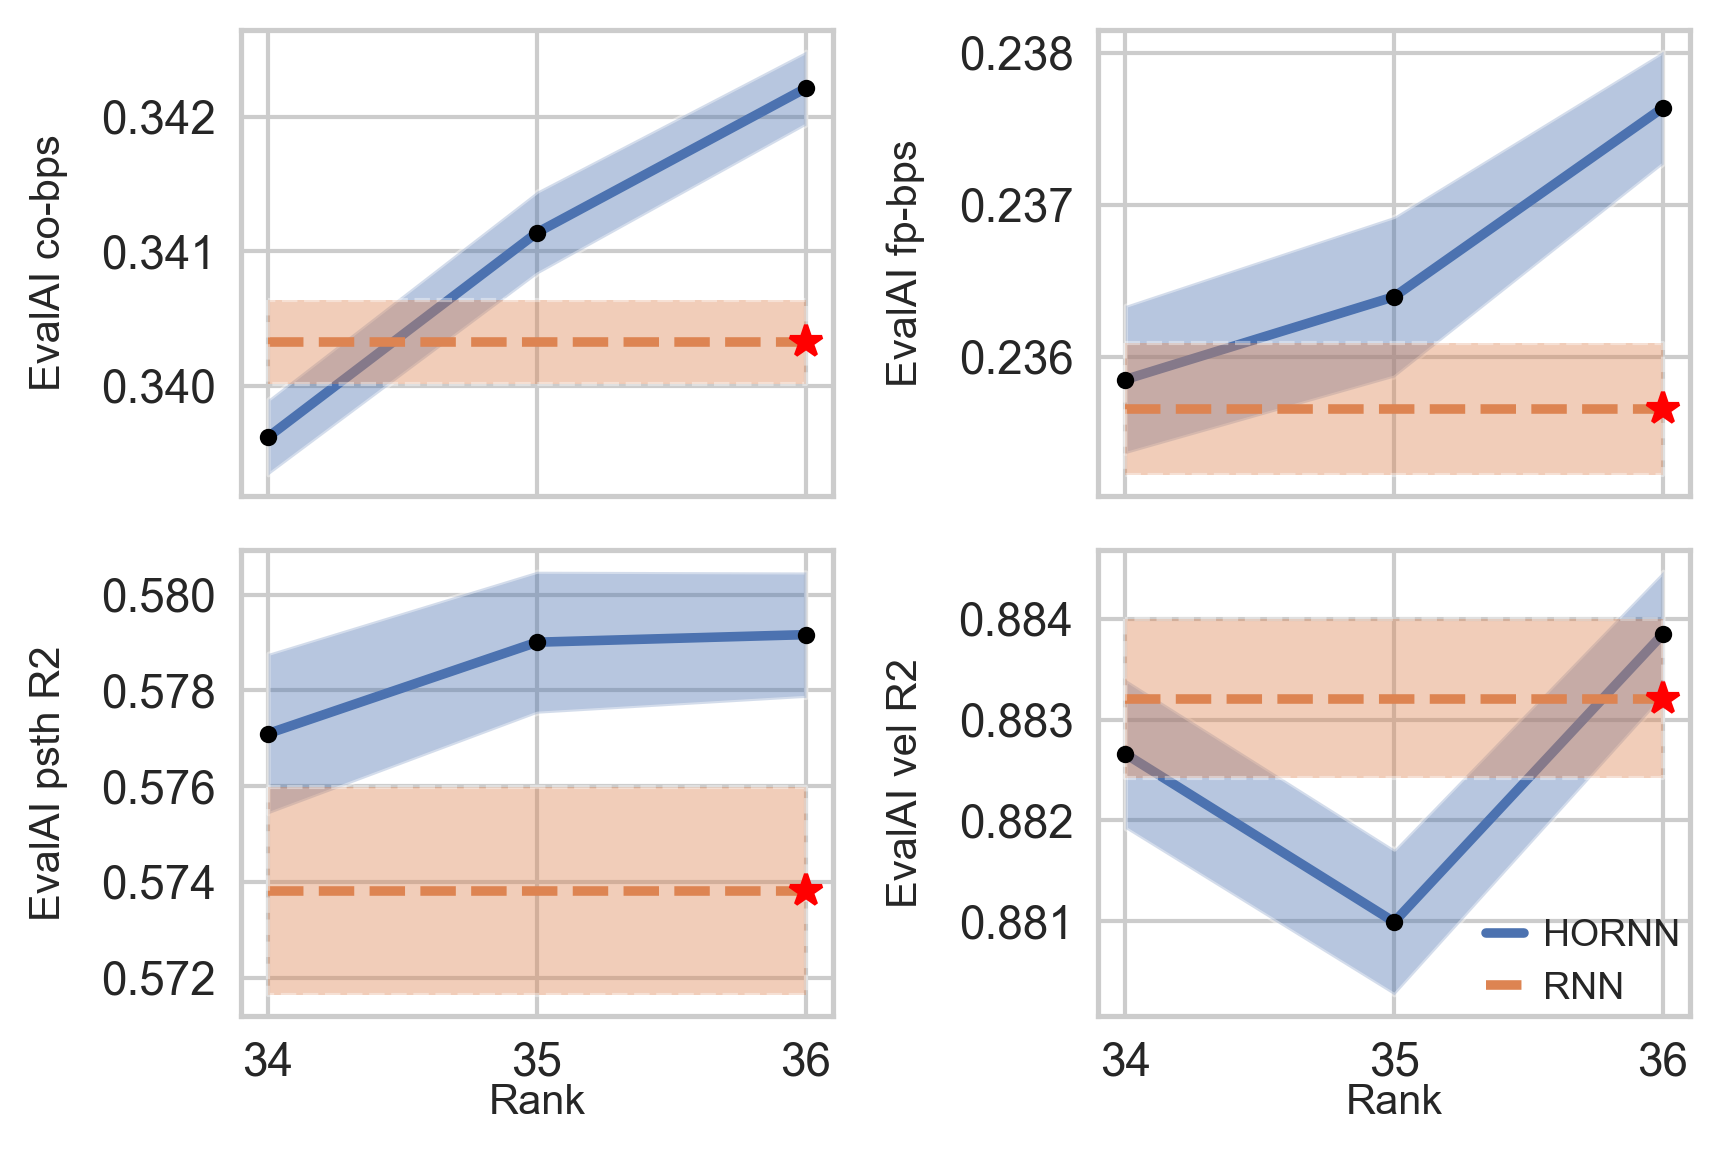

In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Theme FIRST (applies to objects created after this line)
sns.set_theme(style="whitegrid", font_scale=1)

# Prepare data
r = ranks

# Plot
fig, axes = plt.subplots(2, 2, figsize=(6, 4), dpi=300, sharex=True)

for ax, m in zip(axes.flatten(), metric_names):

    records = []
    for model in models:
        mean = np.mean(metrics[m][model], axis=-1)
        ste  = np.std(metrics[m][model], axis=-1) / (samples**0.5)
        d_err, u_err = mean - ste, mean + ste
        for i in range(len(ranks)):
            records.append({
                "Rank": r[i],
                "Metric": mean[i],
                "u_err": u_err[i],
                "d_err": d_err[i],
                "Model": model
            })

    rec_all[fr"NLB reach|{pretty[m]}"] = (records, ref)

    df = pd.DataFrame(records)

    # Plot each model with ribbon
    for model, sub in df.groupby("Model"):
        sns.lineplot(ax=ax, data=sub, x="Rank", y="Metric", linestyle="--" if model == ref else "-",
                     label=model if ax is axes.flatten()[-1] else None,
                     linewidth=2.3, zorder=1)
        ax.fill_between(sub["Rank"], sub["d_err"], sub["u_err"], alpha=0.4, linestyle="--" if model == ref else "-",)
        if model == ref:
          ax.plot(sub["Rank"].iloc[-1],sub["Metric"].iloc[-1],'*', ms=8, color='red')
        else:
          ax.scatter(sub["Rank"], sub["Metric"], s=10, color="black", zorder=2)

    # Labels and formatting
    ax.set_xlabel("Rank", fontsize=10, labelpad=0)
    ax.set_ylabel(f"EvalAI {m}", fontsize=10, labelpad=8)
    ax.set_xticks(ranks)
    ax.tick_params(axis='both', which='major', pad=0)  # avoid negative pad
    ax.grid(True)  # ensure grid even if theme changes

# Legend on the last axes
axes.flatten()[-1].legend(frameon=False, fontsize=9, loc='lower right',
                bbox_to_anchor=(1.04, -0.05),
                columnspacing=0.2, handletextpad=0.5, handlelength=1.0)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/reach_nlb_EvalAI.png", dpi=300, bbox_inches='tight')
plt.show()


## Reach-conditioning

In [17]:
DATA_DIR = ROOT / "data" / "reach_inference" / "reach_condition"

In [18]:
with open(DATA_DIR / "r2s.pkl", "rb") as f:
    r2s = pickle.load(f)

In [19]:
SAMPLES = 30
RANKS = 6

# Prepare data
ranks = range(1,RANKS+1)

metric_names = ['vel $R^2$',]
models = ["RNN", "TBRNN", "HORNN"]

r2s['RNN'] = np.stack([r2s[f'r_{rank}_rnn'] for rank in ranks],axis=0)
r2s['HORNN'] = np.stack([r2s[f'r_{rank}_r_1_hornn'] for rank in ranks],axis=0)
r2s['TBRNN'] = np.stack([r2s[f'r_{rank}_tbrnn'] for rank in ranks],axis=0)

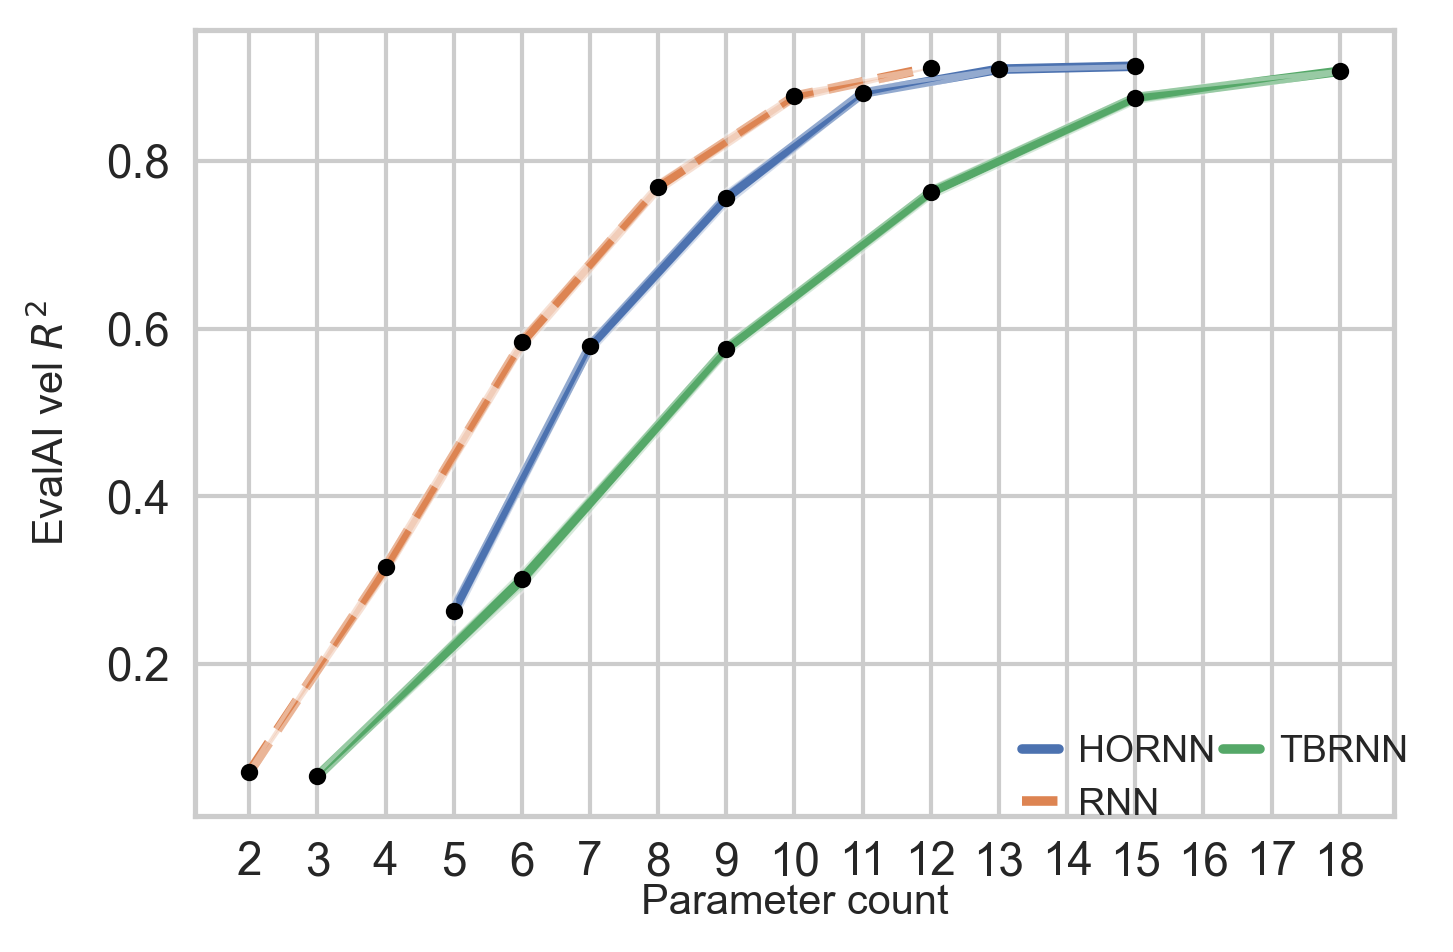

In [20]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Theme FIRST (applies to objects created after this line)
sns.set_theme(style="whitegrid", font_scale=1)

# Plot
fig, axes = plt.subplots(1, 1, figsize=(5, 4/3*2.5), dpi=300)

for ax, m in zip([axes,], metric_names):

    records = []
    for model in models:
        mean = np.mean(r2s[model], axis=-1)
        ste  = np.std(r2s[model], axis=-1) / (SAMPLES**0.5)
        d_err, u_err = mean - ste, mean + ste
        for rank in ranks:
            i = rank-1
            if model == 'TBRNN':
                parameter_count = 3*ranks[i]
            elif model == 'HORNN':
                parameter_count = 2*ranks[i] + 3
            elif model == 'RNN':
                parameter_count = 2*ranks[i]
            else:
                raise ValueError(f"Unknown model {model}")
            records.append({
                "Rank"   : ranks[i],
                "Params" : parameter_count,
                "Metric" : mean[i],
                "u_err"  : u_err[i],
                "d_err"  : d_err[i],
                "Model"  : model
            })

    rec_all[r"Reach conditioning|vel $R^2$"] = (records, ref)
    df = pd.DataFrame(records)

    # Plot each model with ribbon
    for model, sub in df.groupby("Model"):
        sub = sub.sort_values("Params")  # important for fill_between

        sns.lineplot(
            ax=ax, data=sub, x="Params", y="Metric",
            label=model,
            linestyle="--" if model == ref else "-",
            linewidth=2.3, zorder=1
        )

        ax.fill_between(
            sub["Params"].to_numpy(),
            sub["d_err"].to_numpy(),
            sub["u_err"].to_numpy(),
            alpha=0.4
        )

        ax.scatter(sub["Params"], sub["Metric"], s=10, color="black", zorder=2)

    # Labels and formatting
    ax.set_xlabel("Parameter count", fontsize=10, labelpad=0)
    ax.set_ylabel(f"EvalAI {m}", fontsize=10, labelpad=8)

    pmin = int(df["Params"].min())
    pmax = int(df["Params"].max())
    ax.set_xticks(np.arange(pmin, pmax + 1, 1))

    ax.tick_params(axis='both', which='major', pad=0)
    ax.grid(True)

# Legend on the last axes
axes.legend(
    frameon=False, fontsize=9, loc='lower right',
    bbox_to_anchor=(1.04, -0.05), ncol=2,
    columnspacing=0.2, handletextpad=0.5, handlelength=1.0
)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/reach_conditioning.png", dpi=300, bbox_inches='tight')
plt.show()


# Create unifying figure

In [21]:
import copy
r2ss = {}
tasks = ["mante_inference","reach_condition"]
SAMPLES = 30
models = ["RNN", "TBRNN", "HORNN"]

# add mante data
DATA_DIR = ROOT / "data" / "mante_inference"
with open(DATA_DIR / "r2s.pkl", "rb") as f:
    r2s = pickle.load(f)
RANKS = 5

# Prepare data
ranks = range(1,RANKS+1)

r2s['RNN'] = r2s['test']['rnn']
r2s['HORNN'] = r2s['test']['hornn']
r2s['TBRNN'] = r2s['test']['tbrnn']

r2ss["mante_inference"] = (copy.deepcopy(r2s),ranks)

# add reach data
DATA_DIR = ROOT / "data" / "reach_inference" / "reach_condition"
with open(DATA_DIR / "r2s.pkl", "rb") as f:
    r2s = pickle.load(f)

RANKS = 6

# Prepare data
ranks = range(1,RANKS+1)

r2s['RNN'] = np.stack([r2s[f'r_{rank}_rnn'] for rank in ranks],axis=0)
r2s['HORNN'] = np.stack([r2s[f'r_{rank}_r_1_hornn'] for rank in ranks],axis=0)
r2s['TBRNN'] = np.stack([r2s[f'r_{rank}_tbrnn'] for rank in ranks],axis=0)

r2ss["reach_condition"] = (copy.deepcopy(r2s),ranks)


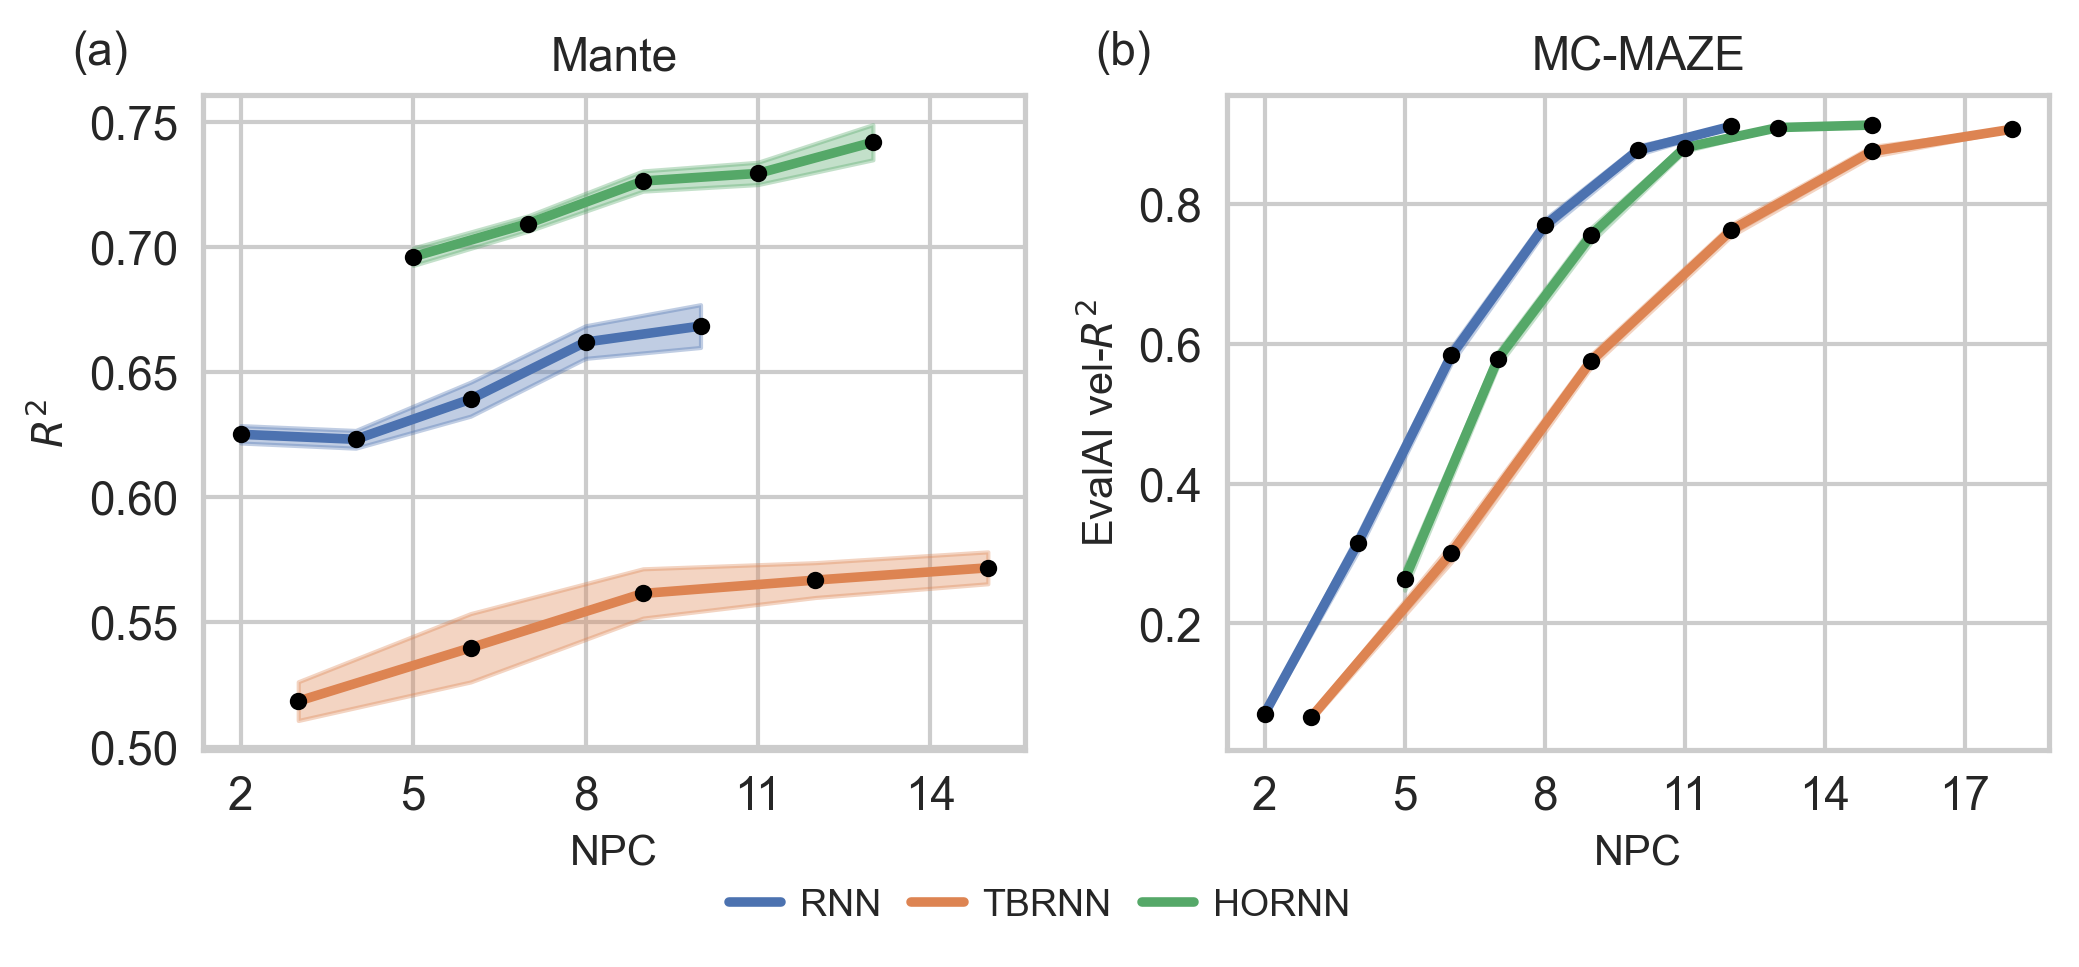

In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", font_scale=1)

# --------------------------------------------------
# Figure settings
# --------------------------------------------------
FIG_W = 7.09   # Cell Reports Methods full-width
FIG_H = 3.2
LINEWIDTH = 2.3
SCATTER_SIZE = 10
PANEL_LABEL_FS = 11
AXIS_LABEL_FS = 10
TITLE_FS = 11
LEGEND_FS = 9

# --------------------------------------------------
# Helper functions
# --------------------------------------------------
def get_param_count(model, rank, scheme):
    if scheme == "scheme1":
        if model == "TBRNN":
            return 3 * rank
        elif model == "HORNN":
            return 3 * rank + 2
        elif model == "RNN":
            return 2 * rank
    elif scheme == "scheme2":
        if model == "TBRNN":
            return 3 * rank
        elif model == "HORNN":
            return 2 * rank + 3
        elif model == "RNN":
            return 2 * rank
    raise ValueError(f"Unknown model ({model}) or scheme ({scheme})")


def build_df(models, ranks, r2s, samples, scheme):
    records = []
    for model in models:
        mean = np.mean(r2s[model], axis=-1)
        ste  = np.std(r2s[model], axis=-1) / np.sqrt(samples)
        d_err, u_err = mean - ste, mean + ste

        for i, rank in enumerate(ranks):
            records.append({
                "Rank": rank,
                "Params": get_param_count(model, rank, scheme),
                "Metric": mean[i],
                "d_err": d_err[i],
                "u_err": u_err[i],
                "Model": model
            })
    return pd.DataFrame(records)


def plot_panel(ax, df, ylabel, panel_label, title):

    # Consistent colors
    palette = sns.color_palette(n_colors=len(models))
    color_map = {model: palette[i] for i, model in enumerate(models)}

    for model, sub in df.groupby("Model"):
        sub = sub.sort_values("Params")
        sns.lineplot(
            ax=ax,
            data=sub,
            x="Params",
            y="Metric",
            label=model,
            linestyle='-',
            linewidth=LINEWIDTH,
            zorder=1,
            color=color_map[model]
        )

        ax.fill_between(
            sub["Params"].to_numpy(),
            sub["d_err"].to_numpy(),
            sub["u_err"].to_numpy(),
            alpha=0.35,
            color=color_map[model]
        )

        ax.scatter(
            sub["Params"],
            sub["Metric"],
            s=SCATTER_SIZE,
            color="black",
            zorder=2
        )

    pmin = int(df["Params"].min())
    pmax = int(df["Params"].max())

    ax.set_xlabel("NPC", fontsize=AXIS_LABEL_FS)
    ax.set_ylabel(ylabel, fontsize=AXIS_LABEL_FS)
    ax.set_xticks(np.arange(pmin, pmax + 1, 3))
    ax.tick_params(axis="both", which="major", pad=0)
    ax.grid(True)
    ax.set_title(title, fontsize=TITLE_FS)

    # panel label: (a), (b)
    ax.text(
        -0.16, 1.1, panel_label,
        transform=ax.transAxes,
        fontsize=PANEL_LABEL_FS,
        fontweight="bold",
        va="top",
        ha="left"
    )

# --------------------------------------------------
# Panel configuration
# --------------------------------------------------
panel_specs = [
    {
        "name": tasks[0],
        "title": "Mante",
        "scheme": "scheme2",
        "ylabel": '$R^2$',
        "panel_label": "(a)",
    },
    {
        "name": tasks[1],
        "title": "MC-MAZE",
        "scheme": "scheme2",
        "ylabel": f"EvalAI vel-{'$R^2$'}",
        "panel_label": "(b)",
    },
]

# --------------------------------------------------
# Build figure
# --------------------------------------------------
fig, axes = plt.subplots(
    1, len(panel_specs),
    figsize=(FIG_W, FIG_H),
    dpi=300,
)

if len(panel_specs) == 1:
    axes = [axes]

for ax, spec in zip(axes, panel_specs):
    r2s, ranks = r2ss[spec["name"]]
    df = build_df(
        models=models,
        ranks=ranks,
        r2s=r2s,
        samples=SAMPLES,
        scheme=spec["scheme"]
    )
    plot_panel(
        ax=ax,
        df=df,
        ylabel=spec["ylabel"],
        panel_label=spec["panel_label"],
        title=spec["title"]
    )

# remove repeated legends from axes
for ax in axes:
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

# shared legend
handles, labels = axes[0].get_legend_handles_labels()
order = [labels.index(l.upper()) for l in models]

fig.legend(
    [handles[i] for i in order],
    [labels[i] for i in order],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.03),
    ncol=3,
    frameon=False,
    fontsize=LEGEND_FS,
    columnspacing=0.8,
    handletextpad=0.5,
    handlelength=1.4
)

plt.tight_layout()
plt.savefig(
    f"{FIG_DIR}/neural_detection.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()